# 02 — English transfer pilot (historical bridge)

This notebook is a **compact pilot / early bridge**: it loads the Kaggle English resume dataset, applies a **preview-level** mapping into the nine-class ontology, and builds **base** city-aware eval rows plus **city-swap** counterfactuals. It was written before the canonical pipeline solidified.

**Today’s roles**

- **`32_english_dataset_alignment.ipynb`** — **canonical** English benchmark: cleaning, full mapping audit, coverage, splits, official artifacts.
- **`54_english_balanced_8class_eval.ipynb`** — **secondary** eval slice on top of 32’s processed data (soft class rebalance).
- **This notebook (02)** — **not** the main English track. Use it for **lightweight** pilot flows, checkpoint discovery, or reproducing **early** pilot CSVs **without** conflicting with 32/54. Prefer **32** outputs for any **authoritative** benchmark numbers.

**Outputs:** `notebooks/results/english_dataset_transfer_pilot/` · `figures/english_dataset_transfer_pilot/`


## Pilot scope (subordinate to 32 / 54)

Mapping here may **differ in detail** from the audited dictionary in **32**—treat **`02_english_category_mapping_review.csv`** as a **pilot preview**, not the contract file. For eval slices aligned with the benchmark, use **`32_english_base_eval_slice.csv`** / **`32_english_city_swap_counterfactuals.csv`** or the processed splits; for softer class balance, use **54**.


In [11]:
import json
import re
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import kagglehub
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Install kagglehub first: pip install kagglehub"
    ) from exc

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ModuleNotFoundError:
    HAS_MPL = False

CWD = Path.cwd()
NOTEBOOK_DIR = CWD if CWD.name == "notebooks" else (CWD / "notebooks")
REPO_ROOT = NOTEBOOK_DIR.parent
FIGURES_DIR = REPO_ROOT / "figures" / "english_dataset_transfer_pilot"
RESULTS_DIR = REPO_ROOT / "notebooks" / "results" / "english_dataset_transfer_pilot"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("Figures dir:", FIGURES_DIR)
print("Results dir:", RESULTS_DIR)


Repo root: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository
Figures dir: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures/english_dataset_transfer_pilot
Results dir: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/results/english_dataset_transfer_pilot


In [12]:
KAGGLE_HANDLE = "rayyankauchali0/resume-dataset"
path = Path(kagglehub.dataset_download(KAGGLE_HANDLE))
print("Downloaded to:", path)

def load_jsonl(path_obj: Path):
    rows = []
    with path_obj.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

def load_dataset(download_dir: Path) -> pd.DataFrame:
    candidates = list(download_dir.rglob("*.csv")) + list(download_dir.rglob("*.jsonl")) + list(download_dir.rglob("*.json"))
    if not candidates:
        zip_candidates = list(download_dir.rglob("*.zip"))
        for archive in zip_candidates:
            with zipfile.ZipFile(archive) as zf:
                extract_dir = archive.with_suffix("")
                zf.extractall(extract_dir)
        candidates = list(download_dir.rglob("*.csv")) + list(download_dir.rglob("*.jsonl")) + list(download_dir.rglob("*.json"))

    if not candidates:
        raise FileNotFoundError(f"No CSV/JSONL/JSON files found under {download_dir}")

    ranked = sorted(candidates, key=lambda p: (p.suffix != ".csv", len(str(p))))
    data_path = ranked[0]
    print("Using data file:", data_path)

    if data_path.suffix == ".csv":
        return pd.read_csv(data_path)
    if data_path.suffix == ".jsonl":
        return load_jsonl(data_path)
    return pd.read_json(data_path)

df = load_dataset(path)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head(3)


Downloaded to: /Users/natashaagapova/.cache/kagglehub/datasets/rayyankauchali0/resume-dataset/versions/1
Using data file: /Users/natashaagapova/.cache/kagglehub/datasets/rayyankauchali0/resume-dataset/versions/1/resumes_dataset.jsonl
Shape: (3500, 12)
Columns: ['ResumeID', 'Category', 'Name', 'Email', 'Phone', 'Location', 'Summary', 'Skills', 'Experience', 'Education', 'Text', 'Source']


,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source
0,REAL_0001,Java Developer,Chad Griffin,contact@email.com,94105 555 4321000 10 ...,"City, State",jessica claire montgomery street san francisco...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco...,Computer Science degree,jessica claire montgomery street san francisco...,ResumeAtlas
1,REAL_0002,Java Developer,Melinda Thomas,contact@email.com,17994568777 2017 2018 20152016 3 ...,"City, State",jared arthur maica java developer 17994568777 ...,"Python, SQL, Git, Linux",jared arthur maica java developer 17994568777 ...,Computer Science degree,jared arthur maica java developer 17994568777 ...,ResumeAtlas
2,REAL_0003,Java Developer,Shannon Mccarthy,contact@email.com,9 555 4321000 94105 8 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas


In [13]:
TEXT_CANDIDATES = ["Resume_Text", "resume_text", "Resume", "Text", "Summary", "Experience", "Education", "Skills"]
CATEGORY_CANDIDATES = ["Category", "category", "Job_Role", "job_role"]
LOCATION_CANDIDATES = ["Location", "location", "City", "city", "Address", "address"]

def first_present(columns, candidates):
    for col in candidates:
        if col in columns:
            return col
    return None

text_col = first_present(df.columns, TEXT_CANDIDATES)
category_col = first_present(df.columns, CATEGORY_CANDIDATES)
location_col = first_present(df.columns, LOCATION_CANDIDATES)

if text_col is None:
    raise ValueError(f"Could not find a resume text column among: {TEXT_CANDIDATES}")

df = df.copy()
df["resume_text_work"] = df[text_col].fillna("").astype(str)
df["text_len_chars"] = df["resume_text_work"].str.len()
df["text_len_words"] = df["resume_text_work"].str.split().str.len()

print("text_col:", text_col)
print("category_col:", category_col)
print("location_col:", location_col)
df[[c for c in [text_col, category_col, location_col, "text_len_words"] if c is not None]].head(5)


text_col: Text
category_col: Category
location_col: Location


,Text,Category,Location,text_len_words
0,jessica claire montgomery street san francisco...,Java Developer,"City, State",204
1,jared arthur maica java developer 17994568777 ...,Java Developer,"City, State",212
2,jessica claire 9 resumesampleexamplecom 555 43...,Java Developer,"City, State",722
3,jessica claire 9 resumesampleexamplecom 555 43...,Java Developer,"City, State",1665
4,jessica claire 100 montgomery st 10th floor xx...,Java Developer,"City, State",497


In [14]:
TARGET_9_CLASSES = [
    "backend_general_dev",
    "web_frontend",
    "sysadmin_devops_network",
    "project_product",
    "sales_account",
    "tech_support_helpdesk",
    "it_governance_leadership",
    "technical_specialized",
    "generic_it_ops",
]

CATEGORY_TO_TARGET = {
    "Data Science": "technical_specialized",
    "Database": "technical_specialized",
    "DevOps Engineer": "sysadmin_devops_network",
    "DotNet Developer": "backend_general_dev",
    "ETL Developer": "backend_general_dev",
    "Hadoop": "technical_specialized",
    "HR": "generic_it_ops",
    "Advocate": "sales_account",
    "Arts": "generic_it_ops",
    "Automation Testing": "technical_specialized",
    "Blockchain": "technical_specialized",
    "Business Analyst": "project_product",
    "Civil Engineer": "generic_it_ops",
    "Designer": "web_frontend",
    "Electrical Engineering": "generic_it_ops",
    "Health and fitness": "generic_it_ops",
    "Java Developer": "backend_general_dev",
    "Mechanical Engineer": "generic_it_ops",
    "Network Security Engineer": "sysadmin_devops_network",
    "Operations Manager": "it_governance_leadership",
    "PMO": "project_product",
    "Python Developer": "backend_general_dev",
    "SAP Developer": "technical_specialized",
    "Sales": "sales_account",
    "Testing": "tech_support_helpdesk",
    "Web Designing": "web_frontend",
}

def normalize_category(value):
    if pd.isna(value):
        return None
    key = str(value).strip()
    if key in CATEGORY_TO_TARGET:
        return CATEGORY_TO_TARGET[key]

    lowered = key.lower()
    if any(token in lowered for token in ["frontend", "web design", "ui", "ux"]):
        return "web_frontend"
    if any(token in lowered for token in ["backend", "python", "java", "dotnet", "developer", "software", "etl"]):
        return "backend_general_dev"
    if any(token in lowered for token in ["devops", "sysadmin", "network", "security", "cloud", "infrastructure"]):
        return "sysadmin_devops_network"
    if any(token in lowered for token in ["product", "project", "business analyst", "pmo"]):
        return "project_product"
    if any(token in lowered for token in ["sales", "account", "advocate", "marketing"]):
        return "sales_account"
    if any(token in lowered for token in ["support", "helpdesk", "testing", "qa"]):
        return "tech_support_helpdesk"
    if any(token in lowered for token in ["manager", "head", "director", "leadership", "operations manager"]):
        return "it_governance_leadership"
    if any(token in lowered for token in ["data", "database", "sap", "blockchain", "hadoop", "ml", "ai"]):
        return "technical_specialized"
    return "generic_it_ops"

if category_col is not None:
    df["target_9_class"] = df[category_col].apply(normalize_category)
else:
    df["target_9_class"] = "generic_it_ops"

mapping_review = (
    df.groupby([category_col, "target_9_class"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    if category_col is not None
    else pd.DataFrame({"target_9_class": df["target_9_class"].value_counts().index, "count": df["target_9_class"].value_counts().values})
)
mapping_review.to_csv(RESULTS_DIR / "02_english_category_mapping_review.csv", index=False)
mapping_review.head(30)


,Category,target_9_class,count
17,Java Developer,backend_general_dev,200
7,Data Science,technical_specialized,200
23,Python Developer,backend_general_dev,200
10,DevOps,sysadmin_devops_network,180
27,SQL Developer,backend_general_dev,180
25,React Developer,backend_general_dev,150
8,Database,technical_specialized,150
35,Web Designing,web_frontend,150
4,Business Analyst,project_product,150
33,Testing,tech_support_helpdesk,150


In [15]:
CITY_PATTERN = re.compile(
    r"\b("
    r"new york|san francisco|los angeles|seattle|austin|chicago|boston|atlanta|dallas|houston|"
    r"london|berlin|paris|madrid|toronto|vancouver|sydney|melbourne|singapore|dubai|"
    r"bangalore|bengaluru|mumbai|delhi|hyderabad|pune"
    r")\b",
    flags=re.IGNORECASE,
)

def extract_city_mentions(text: str) -> list[str]:
    if not text:
        return []
    return sorted({m.group(0).lower() for m in CITY_PATTERN.finditer(text)})

df["city_mentions"] = df["resume_text_work"].apply(extract_city_mentions)
df["n_city_mentions"] = df["city_mentions"].apply(len)
df["has_city_mention"] = df["n_city_mentions"] > 0

location_summary = pd.DataFrame(
    {
        "rows_total": [len(df)],
        "rows_with_city_mentions": [int(df["has_city_mention"].sum())],
        "share_with_city_mentions": [float(df["has_city_mention"].mean()) if len(df) else 0.0],
        "median_words": [float(df["text_len_words"].median()) if len(df) else 0.0],
    }
)
location_summary.to_csv(RESULTS_DIR / "02_english_location_summary.csv", index=False)

city_counts = (
    df.explode("city_mentions")
    .dropna(subset=["city_mentions"])
    .groupby("city_mentions")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
city_counts.to_csv(RESULTS_DIR / "02_english_city_counts.csv", index=False)

location_summary


,rows_total,rows_with_city_mentions,share_with_city_mentions,median_words
0,3500,1577,0.450571,257.0


In [16]:
SWAP_CITIES = [
    "new york",
    "san francisco",
    "london",
    "berlin",
    "singapore",
]

def swap_cities_in_text(text: str, target_city: str) -> str:
    if not isinstance(text, str) or not text:
        return text

    def repl(match):
        original = match.group(0)
        if original.isupper():
            return target_city.upper()
        if original[:1].isupper():
            return target_city.title()
        return target_city.lower()

    return CITY_PATTERN.sub(repl, text)

english_eval = df[df["has_city_mention"]].copy()
english_eval["source_city"] = english_eval["city_mentions"].apply(lambda xs: xs[0] if xs else None)
english_eval = english_eval[english_eval["source_city"].notna()].copy()

counterfactual_rows = []
for _, row in english_eval.iterrows():
    for swap_city in SWAP_CITIES:
        if row["source_city"] == swap_city:
            continue
        swapped_text = swap_cities_in_text(row["resume_text_work"], swap_city)
        counterfactual_rows.append(
            {
                "row_id": int(row.name),
                "target_9_class": row["target_9_class"],
                "source_city": row["source_city"],
                "swap_city": swap_city,
                "original_text": row["resume_text_work"],
                "swapped_text": swapped_text,
            }
        )

counterfactual_df = pd.DataFrame(counterfactual_rows)
base_eval_df = english_eval[["resume_text_work", "target_9_class", "source_city"]].rename(columns={"resume_text_work": "original_text"})

base_eval_df.to_csv(RESULTS_DIR / "02_english_base_eval_slice.csv", index=False)
counterfactual_df.to_csv(RESULTS_DIR / "02_english_city_swap_counterfactuals.csv", index=False)

print("Base eval rows:", len(base_eval_df))
print("Counterfactual rows:", len(counterfactual_df))
counterfactual_df.head(10)


Base eval rows: 1577
Counterfactual rows: 7161


,row_id,target_9_class,source_city,swap_city,original_text,swapped_text
0,0,backend_general_dev,san francisco,new york,jessica claire montgomery street san francisco...,jessica claire montgomery street new york ca 9...
1,0,backend_general_dev,san francisco,london,jessica claire montgomery street san francisco...,jessica claire montgomery street london ca 941...
2,0,backend_general_dev,san francisco,berlin,jessica claire montgomery street san francisco...,jessica claire montgomery street berlin ca 941...
3,0,backend_general_dev,san francisco,singapore,jessica claire montgomery street san francisco...,jessica claire montgomery street singapore ca ...
4,1,backend_general_dev,los angeles,new york,jared arthur maica java developer 17994568777 ...,jared arthur maica java developer 17994568777 ...
5,1,backend_general_dev,los angeles,san francisco,jared arthur maica java developer 17994568777 ...,jared arthur maica java developer 17994568777 ...
6,1,backend_general_dev,los angeles,london,jared arthur maica java developer 17994568777 ...,jared arthur maica java developer 17994568777 ...
7,1,backend_general_dev,los angeles,berlin,jared arthur maica java developer 17994568777 ...,jared arthur maica java developer 17994568777 ...
8,1,backend_general_dev,los angeles,singapore,jared arthur maica java developer 17994568777 ...,jared arthur maica java developer 17994568777 ...
9,2,backend_general_dev,san francisco,new york,jessica claire 9 resumesampleexamplecom 555 43...,jessica claire 9 resumesampleexamplecom 555 43...


In [17]:
MODEL_CANDIDATES = [
    ("baseline", REPO_ROOT / "models" / "bert_9classes_final"),
    ("groupdro", REPO_ROOT / "models" / "bert_gdro_eta01_2ep"),
    ("label_smoothing", REPO_ROOT / "models" / "bert_label_smoothing"),
    ("combined_best", REPO_ROOT / "models" / "combined_scrubbing_groupdro" / "final"),
]

available_models = [(name, path) for name, path in MODEL_CANDIDATES if path.exists()]
if not available_models:
    print("No local checkpoints found under repo/models. Dataset preparation is complete; run evaluation on Natasha's machine where checkpoints exist.")
else:
    print("Found local checkpoints:")
    for name, path in available_models:
        print(" -", name, "->", path)


No local checkpoints found under repo/models. Dataset preparation is complete; run evaluation on Natasha's machine where checkpoints exist.


In [18]:
evaluation_plan = pd.DataFrame(
    [
        {
            "priority": 1,
            "step": "Prefer 32 mapping audit for benchmark; use 02 mapping CSV only as pilot preview",
            "why": "32 is canonical; avoid treating 02 as source of truth for ontology mapping",
            "artifact": "notebooks/results/english_dataset_alignment/32_english_category_mapping_review.csv (canonical); 02_english_category_mapping_review.csv (pilot)",
        },
        {
            "priority": 2,
            "step": "Run models on English eval slices (prefer 32 base eval; 02 slice is legacy)",
            "why": "32 aligns with benchmark splits; 02 replicates early pilot columns",
            "artifact": "32_english_base_eval_slice.csv (canonical); 02_english_base_eval_slice.csv (pilot)",
        },
        {
            "priority": 3,
            "step": "City-swap probes (prefer 32 counterfactuals)",
            "why": "Same logic as pilot; 32 exports are the benchmark-standard paths",
            "artifact": "32_english_city_swap_counterfactuals.csv (canonical); 02_english_city_swap_counterfactuals.csv (pilot)",
        },
        {
            "priority": 4,
            "step": "Optional: soft eval mix via 54; fine-tune only if needed",
            "why": "54 reduces extreme skew without redefining the benchmark",
            "artifact": "notebooks/results/english_balanced_eval/english_balanced_8class_eval.csv",
        },
    ]
)
evaluation_plan.to_csv(RESULTS_DIR / "02_english_next_steps_plan.csv", index=False)
evaluation_plan



,priority,step,why,artifact
0,1,Manual review of English->9-class mapping,Prevents garbage transfer metrics from label m...,02_english_category_mapping_review.csv
1,2,Run existing strongest models on the English b...,Checks out-of-domain generalization before any...,02_english_base_eval_slice.csv
2,3,Run city-swap on the English counterfactual slice,Measures location sensitivity on English resum...,02_english_city_swap_counterfactuals.csv
3,4,Only then decide whether to fine-tune challeng...,Avoids another 15 training runs if transfer al...,decision_after_eval


In [19]:
quick_answer = {
    "should_we_do_city_swap_on_english": True,
    "canonical_english_benchmark": "notebooks/32_english_dataset_alignment.ipynb",
    "secondary_eval_slice": "notebooks/54_english_balanced_8class_eval.ipynb",
    "pilot_role": "historical_bridge_lightweight_transfer_prep",

    "should_we_train_again_immediately": False,
    "recommended_first_move": "map English labels into the current 9-class space and evaluate existing strongest checkpoints first",
    "why": [
        "Canonical label space and splits come from notebook 32; pilot rows here are for continuity only.",
        "Existing models may already transfer well enough to justify evaluation-before-retraining.",
        "If transfer fails, use 32 (and optionally 54) exports as the standard English benchmark artifacts.",
    ],
}
pilot_manifest = {
    "notebook": "02_english_dataset_transfer_pilot.ipynb",
    "role": "english_transfer_pilot_bridge",
    "results_dir": str(RESULTS_DIR),
    "figures_dir": str(FIGURES_DIR),
    "canonical_benchmark": "notebooks/32_english_dataset_alignment.ipynb",
    "secondary_eval": "notebooks/54_english_balanced_8class_eval.ipynb",
    "pilot_artifacts_glob": "02_english_*.csv",
}
(RESULTS_DIR / "02_english_pilot_manifest.json").write_text(
    json.dumps(pilot_manifest, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

(RESULTS_DIR / "02_english_quick_answer.json").write_text(
    json.dumps(quick_answer, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
print(json.dumps(quick_answer, indent=2, ensure_ascii=False))




{
  "should_we_do_city_swap_on_english": true,
  "should_we_train_again_immediately": false,
  "recommended_first_move": "map English labels into the current 9-class space and evaluate existing strongest checkpoints first",
  "why": [
    "The dataset must be aligned to the current label space before city-swap numbers are interpretable.",
    "Existing models may already transfer well enough to justify evaluation-before-retraining.",
    "If transfer fails, the prepared English counterfactual slice becomes the benchmark for the next training wave."
  ]
}


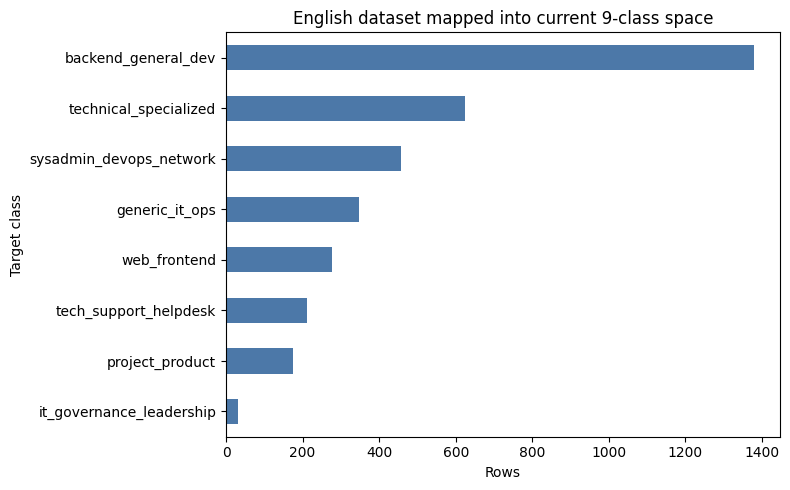

In [20]:
if HAS_MPL and not df.empty:
    class_counts = df["target_9_class"].value_counts().sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    class_counts.plot(kind="barh", ax=ax, color="#4c78a8")
    ax.set_title("English dataset mapped into current 9-class space")
    ax.set_xlabel("Rows")
    ax.set_ylabel("Target class")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "02_english_target9_distribution.png", dpi=180, bbox_inches="tight")
    plt.show()


## Key takeaways

- **What 02 is now.** A **historical / pilot bridge**: same rough ideas as early English work (load → map preview → city eval → counterfactuals → checkpoint hints) but **explicitly subordinate** to **32** (benchmark) and **54** (soft eval).
- **What not to use it for.** Do **not** treat 02 as the **canonical** mapping or split definition; shipping numbers for the thesis should trace to **32** (and optionally **54**) artifacts.
- **When 02 is still useful.** Quick **local** pilot, teaching the flow, or comparing **early** `02_*` CSVs with **`32_*`** for consistency checks—plus **`02_english_pilot_manifest.json`** as a pointer to the newer pipeline.
